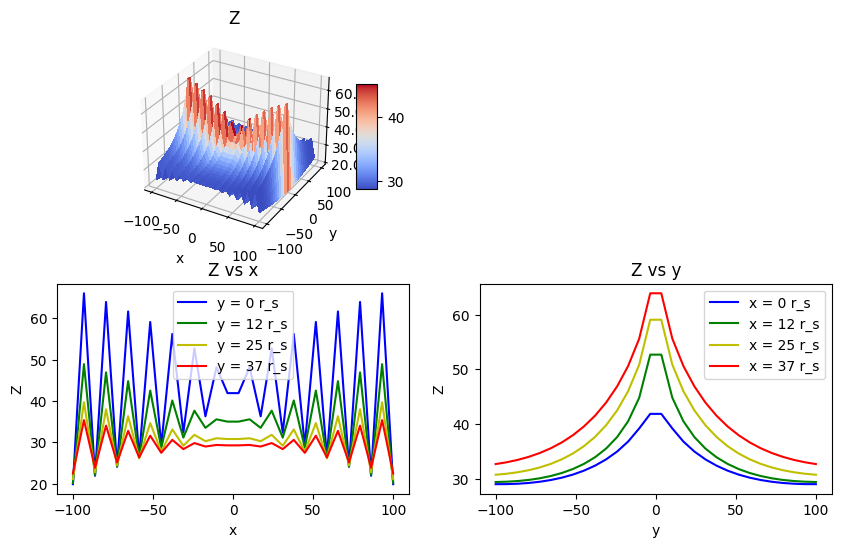

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

'''
Evaluate z by taking advantage of discretized grid rather than integration.
'''

# =========================
# Spacetime Metric
# ========================
# Linearized Schwarzschild
def g_xx(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + 2*GM * (x**2 / r**3)
def g_xy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 2*GM * (x*y / r**3)
def g_yy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + 2*GM * (y**2 / r**3)

# =========================
# Embedding PDE
# =========================
def partial_x_Z(x, y):
    return np.sqrt(g_xx(x, y) - 1)
def partial_y_Z(x, y):
    return np.sqrt(g_yy(x, y) - 1)
# sign checker
def sign_condition_check(x, y, sign_parital_x, sign_parital_y):
    condition_met = False
    dz_dr = x * sign_parital_x*partial_x_Z(x, y) + y * sign_parital_y*partial_y_Z(x, y)
    if dz_dr > 0:
        condition_met = True
    return condition_met
def pick_partialx_sign(x_coord, y_coord):
    '''
    picks either the positive or negative solution at each point in space
    '''
    partialx_sign, partialy_sign = 1, 1
    if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
        return partialx_sign
    else:
        partialx_sign, partialy_sign = -1, 1
        if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
            return partialx_sign
        else:
            partialx_sign, partialy_sign = 1, -1
            if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
                return partialx_sign
            else:
                partialx_sign, partialy_sign = -1, -1
                if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
                    return partialx_sign
                else:
                    print(f'pick_sign() : NO SIGN PAIR FOUND AT ({x_coord}, {y_coord})')
    return None

# ========================
# values for the system
# ========================
GM = 1
x0 = 10
n_steps = 30 # must be even 

# ========================
# Discretize the metric
# =======================
# values
x_start, x_end = -100, 100
y_start, y_end = -100, 100
dx = (x_end - x_start) / (n_steps - 1)
dy = (y_end - y_start) / (n_steps - 1)
# create the grid
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)
r = np.sqrt(x_meshed**2 + y_meshed**2)
# discretize the metric
g_xx_discretized = g_xx(x_meshed, y_meshed)
g_xy_discretized = g_xy(x_meshed, y_meshed)
g_yy_discretized = g_yy(x_meshed, y_meshed)

# ========================
# Evaluate Z(x,y)
# =======================
# initialize Z
z = np.zeros_like(x_meshed)
# evaluate the boundary condition
left_boundary = 2 * np.sqrt(r[0] - GM)
right_boundary = 2 * np.sqrt(r[-1] - GM)
# apply the boundary conditions
z[:, 0] = left_boundary    # for odd  points
z[:, -1] = right_boundary  # for even points
# evaluate z(x,y)
for y in range(n_steps): # even indeces
    for x in range(2, n_steps, 2):
        sign_partialx = pick_partialx_sign(x, y)
        z[:, x] = sign_partialx * 2 * dx * np.sqrt(g_xx_discretized[:,x-1] - 1) + z[:,x-2]
for y in range(n_steps): # odd indeces
    for x in range(n_steps-3, 0, -2):
        sign_partialx = pick_partialx_sign(x, y)
        z[:, x] = sign_partialx * 2 * dx * np.sqrt(g_xx_discretized[:,x+1] - 1) + z[:,x+2]


# ========================
# Plots
# =======================
# the function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)} r_s')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)} r_s')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
'''
# plot the metric
plot_3d_and_slice(g_xx_discretized, 'g_xx')
plot_3d_and_slice(g_xy_discretized, 'g_xy')
plot_3d_and_slice(g_yy_discretized, 'g_yy')
'''
# plot Z
plot_3d_and_slice(z, 'Z')

In [ ]:
### Value Checks
''' CHECK COMPLETE
# r
plot_3d_and_slice(r, 'r')

# boundary conditions
print(left_boundary)
print(right_boundary)

# shape of z
print(f'\nz.shape = {z.shape}\n')

# values around the boundaries
print(f'z[:10, 0] = {z[:10, 0]}')
print(f'z[:10, 1] = {z[:10, 1]}')
print(f'z[:10, 2] = {z[:10, 2]}')
print(f'z[:10, 3] = {z[:10, 3]}')
print()
print(f'z[:10, -4] = {z[:10, -4]}')
print(f'z[:10, -3] = {z[:10, -3]}')
print(f'z[:10, -2] = {z[:10, -2]}')
print(f'z[:10, -1] = {z[:10, -1]}')
print()
print(f'z[0, :10] = {z[0, :10]}')
print(f'z[1, :10] = {z[1, :10]}')
print(f'z[2, :10] = {z[2, :10]}')
print(f'z[3, :10] = {z[3, :10]}')
print()
print(f'z[-4, :10] = {z[-4, :10]}')
print(f'z[-3, :10] = {z[-3, :10]}')
print(f'z[-2, :10] = {z[-2, :10]}')
print(f'z[-1, :10] = {z[-1, :10]}')
'''

z[:10, 0] = [23.69990348 23.29221433 22.89357068 22.50624773 22.13283645 21.77625143
 21.43972228 21.12676206 20.84110566 20.5866126 ]
z[:10, 1] = [23.12495831 22.68564611 22.25374253 21.83167258 21.42227287 21.02882172
 20.65505183 20.30513473 19.98362492 19.69535203]
z[:10, 2] = [22.56276066 22.09016688 21.62292122 21.16354685 20.71508416 20.28115267
 19.865997   19.47450174 19.11215539 18.7849413 ]
z[:10, 3] = [22.01650981 21.50911883 21.00453817 20.50531189 20.01461181 19.53634243
 19.0752364  18.63692056 18.22792366 17.85558904]

z[:10, -4] = [22.01650981 21.50911883 21.00453817 20.50531189 20.01461181 19.53634243
 19.0752364  18.63692056 18.22792366 17.85558904]
z[:10, -3] = [22.56276066 22.09016688 21.62292122 21.16354685 20.71508416 20.28115267
 19.865997   19.47450174 19.11215539 18.7849413 ]
z[:10, -2] = [23.12495831 22.68564611 22.25374253 21.83167258 21.42227287 21.02882172
 20.65505183 20.30513473 19.98362492 19.69535203]
z[:10, -1] = [23.69990348 23.29221433 22.89357068 2

In [33]:
''' TEST pick_partialx_sign() '''
x_test, y_test = 0 , -10
sign = pick_partialx_sign(x_test, y_test)
print(f'Test point ({x_test}, {y_test})\nSign of partial_x = {sign}')

Test point (0, -10)
Sign of partial_x = 1
